In [1]:
from google.colab import files
uploaded = files.upload()


Saving students.csv to students.csv


In [3]:
import pandas as pd
df = pd.read_csv("students.csv")

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.columns)

(15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.00000

In [5]:
print(df['passed'].value_counts())

passed
1    9
0    6
Name: count, dtype: int64


In [6]:
subject_cols = ['math','science','english','history','pe']

pass_avg = df[df['passed']==1][subject_cols].mean()
fail_avg = df[df['passed']==0][subject_cols].mean()

print("Pass avg:\n", pass_avg)
print("Fail avg:\n", fail_avg)

Pass avg:
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64
Fail avg:
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [7]:
df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]
print(top_student['name'], top_student['overall_avg'])

Diana 94.0


In [8]:
import matplotlib.pyplot as plt

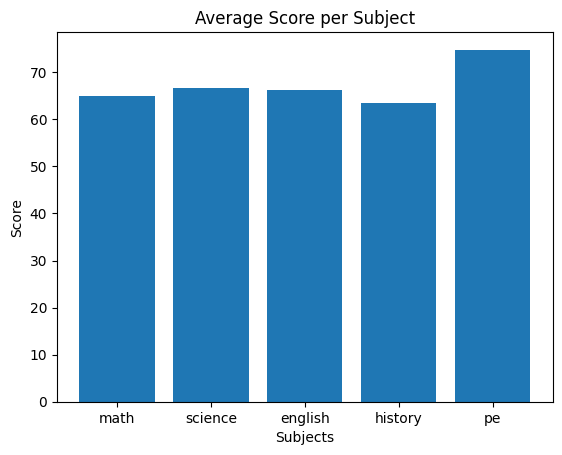

In [9]:
avg_scores = df[subject_cols].mean()

plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")

plt.savefig("plot1_bar.png")
plt.show()

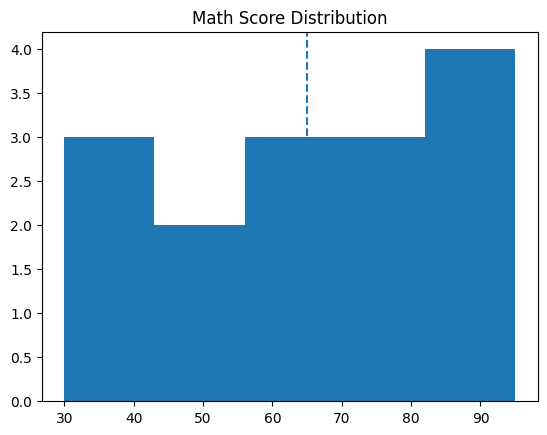

In [10]:
plt.hist(df['math'], bins=5)

mean_val = df['math'].mean()
plt.axvline(mean_val, linestyle='dashed')

plt.title("Math Score Distribution")

plt.savefig("plot2_hist.png")
plt.show()

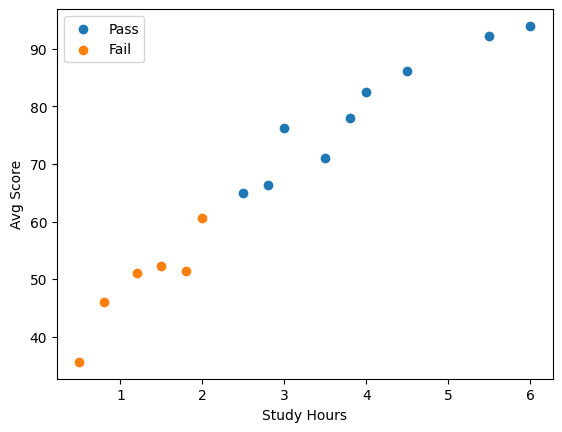

In [11]:
df['avg_score'] = df[subject_cols].mean(axis=1)

pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.legend()
plt.xlabel("Study Hours")
plt.ylabel("Avg Score")

plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_3796/290236297.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])


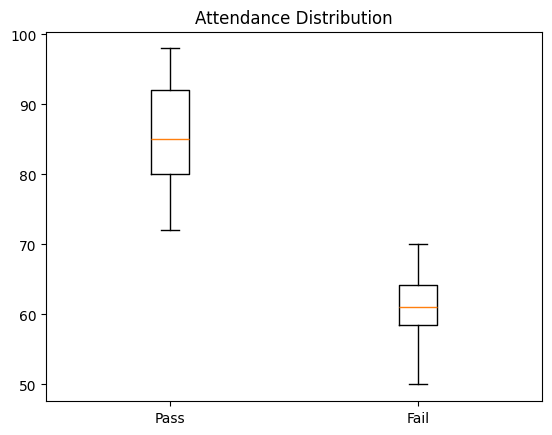

In [12]:
pass_att = pass_df['attendance_pct']
fail_att = fail_df['attendance_pct']

plt.boxplot([pass_att, fail_att], labels=['Pass','Fail'])

plt.title("Attendance Distribution")

plt.savefig("plot4_box.png")
plt.show()

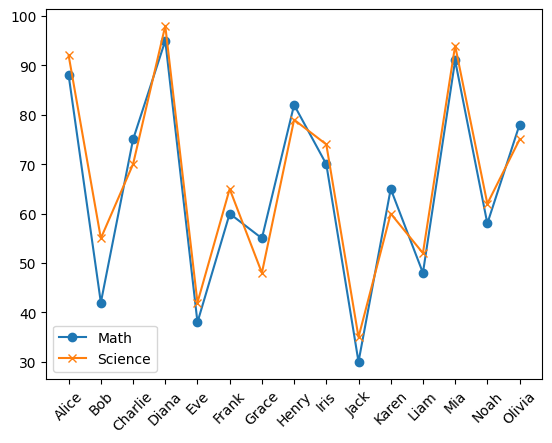

In [13]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [14]:
import seaborn as sns

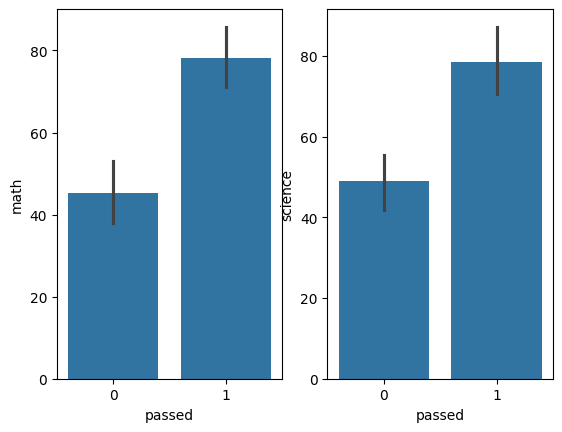

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2)

sns.barplot(data=df, x='passed', y='math', ax=ax1)
sns.barplot(data=df, x='passed', y='science', ax=ax2)

plt.savefig("plot6_seaborn_bar.png")
plt.show()

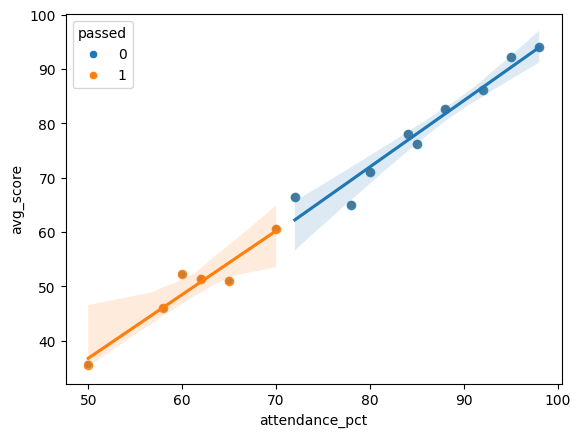

In [16]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=pass_df, x='attendance_pct', y='avg_score')
sns.regplot(data=fail_df, x='attendance_pct', y='avg_score')

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [17]:
# Seaborn made plotting easier and cleaner compared to matplotlib.
# It required less manual formatting and automatically handled grouping.
# Matplotlib gave more control but required more code.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [19]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training accuracy:", model.score(X_train_scaled, y_train))

Training accuracy: 1.0


In [21]:
y_pred = model.predict(X_test_scaled)

print("Test accuracy:", model.score(X_test_scaled, y_test))

Test accuracy: 1.0


In [22]:
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(name, actual, pred, result)

Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅


In [23]:
coeffs = model.coef_[0]
features = X.columns

pairs = list(zip(features, coeffs))
pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print(pairs)

[('english', np.float64(0.8125127982724648)), ('attendance_pct', np.float64(0.521876340433209)), ('study_hours_per_day', np.float64(0.4844326627100155)), ('pe', np.float64(0.47497406284967797)), ('math', np.float64(0.43794393086873595)), ('science', np.float64(0.3230097624690249)), ('history', np.float64(0.26292892629062437))]


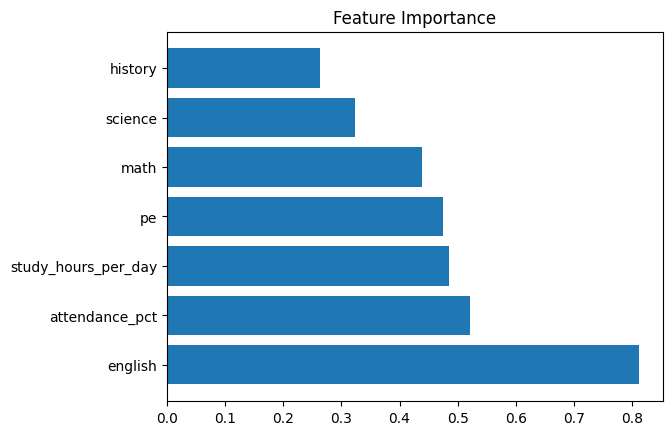

In [24]:
values = [p[1] for p in pairs]
names = [p[0] for p in pairs]

plt.barh(names, values)
plt.title("Feature Importance")

plt.show()

In [25]:
new_student = [[75,70,68,65,80,82,3.2]]

new_scaled = scaler.transform(new_student)

pred = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("Prediction:", "Pass" if pred[0]==1 else "Fail")
print("Probability:", prob)

Prediction: Pass
Probability: [[0.09203526 0.90796474]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
